In [1]:
%cd /app

/app


In [2]:
import argparse
import os
import sys

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import torch
torch.multiprocessing.set_start_method('spawn')

import jax
from lob.encoding import Vocab, Message_Tokenizer

from lob import inference_no_errcorr as inference
from lob.init_train import init_train_state, load_checkpoint, load_metadata, load_args_from_checkpoint

from lob import inference_no_errcorr as inference
import lob.encoding as encoding
import preproc as preproc

import jax.numpy as jnp
import numpy as np

from pathlib import Path
import os

import pandas as pd

import pandas as pd
import plotly.graph_objs as go
import yaml
import pickle

from filtration_utils import summary_table, build_zero_padded_series, plot_midprice_series_with_insertions, prepare_volatility_filtered_series, plot_midprice_series_with_mean_std
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from typing import Callable, Tuple, Optional, List, Dict

import ipywidgets as widgets
from IPython.display import display, clear_output

import os, glob, re

CUDA backend failed to initialize: jaxlib/cuda/versions_helpers.cc:98: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
/opt/conda/envs/myenv/lib/python3.12/site-packages/torch/cuda/__init__.py:619: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
2025-09-30 20:59:32.006606: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
def from_historical_folder_to_midprices(experiment_name):
    # experiment_name = 'exp_89_20250828_194553_sell_1024'  #       exp_85_20250823_020427_1024

    CONFIG_PATH = f"/app/data_saved/{experiment_name}/used_config.yaml"

    with open(CONFIG_PATH, 'r') as f:
        config = yaml.safe_load(f)

    midprice_step_size  = config["midprice_step_size"]
    hist_msgs           = config["n_messages"]
    n_gen_msgs          = config["n_gen_msgs"]
            

    merged = summary_table(experiment_name)
    x, all_series = build_zero_padded_series(hist_msgs, n_gen_msgs, midprice_step_size, merged)

    return merged, all_series

In [4]:
def compute_avg_returns(combined_df):
    all_returns = []
    buy_returns = []
    sell_returns = []

    for _, row in combined_df.iterrows():
        data_array = np.array(row['merged_data'])
        returns = data_array - data_array[0]
        
        if row['id']<1000000:
            buy_returns.append(returns)
            all_returns.append(returns)
        elif row['id']>=1000000:
            sell_returns_inverted = returns * -1.0
            sell_returns.append(sell_returns_inverted)
            all_returns.append(sell_returns_inverted)

    all_returns = np.array(all_returns)
    avg_all_returns = np.mean(all_returns, axis=0)
    std_all_returns = np.std(all_returns, axis=0)
    return all_returns, avg_all_returns, std_all_returns

In [5]:
def build_and_merge(folder, batch_prefix, inp_prefix):
    # STEP 1: load every .npy (shape (batch_size, time, feat)) into a DataFrame
    files   = glob.glob(os.path.join(folder, "*.npy"))
    rx_iter = re.compile(rf"{re.escape(batch_prefix)}_\[(.+)\]_iter_(\d+)\.npy$")
    rx_inp  = re.compile(rf"{re.escape(inp_prefix)}_\[(.+)\]\.npy$")
    rec = []
    for f in files:
        nm = os.path.basename(f)
        m  = rx_iter.match(nm)
        if m:
            rng, itr = m.group(1).replace(" ", ""), int(m.group(2))
        else:
            m2 = rx_inp.match(nm)
            if not m2:
                continue
            rng, itr = m2.group(1).replace(" ", ""), 0

        batch = np.load(f)  # shape (batch_size, time, features)
        print(f"Loaded {nm} with shape {batch.shape}")

        rec.append({"range": rng, "iteration": itr, "batch": batch})
    df = pd.DataFrame(rec).sort_values(["range","iteration"]).reset_index(drop=True)

    # STEP 2: parse the comma‐separated list of IDs into Python lists
    df["ids"] = df["range"].str.split(",").apply(lambda L: [int(x) for x in L])

    # explode each batch into one row per sample, с учётом slicing
    rows = []
    for _, r in df.iterrows():
        for idx, sample_id in enumerate(r["ids"]):
            single = r["batch"][idx]   # shape (time, features)

            # ====== здесь происходит нужный slice ======
            if r["iteration"] > 0:
                n_keep = 51 if r["iteration"] <= num_insertions else 50
                single = single[-n_keep:, :]
            # ============================================

            rows.append({
                "id":        sample_id,
                "iteration": r["iteration"],
                "data":      single
            })

    df_sorted = pd.DataFrame(rows).sort_values(["id","iteration"]).reset_index(drop=True)

    merged = []
    for id_val, grp in df_sorted.groupby("id", sort=True):
        arrs = [row.data for _, row in grp.iterrows()]
        big  = np.concatenate(arrs, axis=0)
        merged.append({"id": id_val, "merged_data": big})
    merged_df = pd.DataFrame(merged).sort_values("id").reset_index(drop=True)

    return df, df_sorted, merged_df


def process_m_b_data(experiment_name):
    b_folder      = f"/app/data_saved/{experiment_name}/b_seq_gen_doubled"
    b_batch_pref  = "b_seq_gen_doubled_batch"
    b_inp_pref    = "b_seq_inp"

    m_folder      = f"/app/data_saved/{experiment_name}/msgs_decoded_doubled"
    m_batch_pref  = "msgs_decoded_doubled_batch"
    m_inp_pref    = "m_seq_raw_inp"

    _, b_sorted, b_merged = build_and_merge(b_folder, b_batch_pref, b_inp_pref)
    _, m_sorted, m_merged = build_and_merge(m_folder, m_batch_pref, m_inp_pref)

    b_dict = { int(r.id): np.array(r.merged_data) for _, r in b_merged.iterrows() }
    m_dict = { int(r.id): np.array(r.merged_data) for _, r in m_merged.iterrows() }

    for d in (b_dict, m_dict):
        for key, arr in d.items():
            zero = np.zeros((1, arr.shape[1]), dtype=arr.dtype)
            d[key] = np.vstack([zero, arr])
    return m_dict, b_dict

In [6]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- helpers ---------------------------------------------------------------

def split_l2_vector(vec: np.ndarray,
                    ask_before_bid: bool = True,
                    odd_policy: str = "drop_center"):
    """
    Split a 1D L2 vector into (ask_vec, bid_vec).

    - If len(vec) is even: split into two equal halves.
    - If len(vec) is odd and odd_policy == "drop_center":
        drop the center column (index len//2) and split the remainder evenly.
    - odd_policy can be "drop_center", "drop_last", or "error".
    Returns (ask_vec, bid_vec, dropped_index_or_None)
    """
    n = int(vec.shape[0])

    if n % 2 == 0:
        k = n // 2
        if ask_before_bid:
            ask, bid = vec[:k], vec[k:]
        else:
            bid, ask = vec[:k], vec[k:]
        return ask, bid, None

    # odd length:
    if odd_policy == "drop_center":
        mid = n // 2
        # build a new vector without the center element
        if ask_before_bid:
            ask = vec[:mid]
            bid = vec[mid+1:]
        else:
            bid = vec[:mid]
            ask = vec[mid+1:]
        return ask, bid, mid

    elif odd_policy == "drop_last":
        vec2 = vec[:-1]
        return split_l2_vector(vec2, ask_before_bid=ask_before_bid, odd_policy="drop_center")

    elif odd_policy == "error":
        raise ValueError(f"Odd L2 width ({n}); cannot split evenly without a policy.")

    else:
        raise ValueError(f"Unknown odd_policy={odd_policy!r}")


def compute_queued_volumes_over_time(book_array: np.ndarray,
                                     l2_start: int = 240,
                                     l2_end: int = 263,
                                     ask_before_bid: bool = True,
                                     odd_policy: str = "drop_center",
                                     use_abs: bool = True):
    """
    For each time t, sum queued volume on ASK and BID from the L2 slice [l2_start:l2_end).
    Handles odd width by the given odd_policy (default: drop the center column).
    """
    T = book_array.shape[0]
    bid_vol = np.empty(T, dtype=float)
    ask_vol = np.empty(T, dtype=float)

    for t in range(T):
        vec = book_array[t, l2_start:l2_end].astype(float)
        ask_vec, bid_vec, _ = split_l2_vector(vec, ask_before_bid=ask_before_bid, odd_policy=odd_policy)
        if use_abs:
            bid_vol[t] = float(np.sum(np.abs(bid_vec)))
            ask_vol[t] = float(np.sum(np.abs(ask_vec)))
        else:
            bid_vol[t] = float(np.sum(bid_vec))
            ask_vol[t] = float(np.sum(ask_vec))

    total = bid_vol + ask_vol
    return bid_vol, ask_vol, total


# --- main widget -----------------------------------------------------------

def interactive_lob_plot(b_seq_inp, msg_seq_raw,
                         l2_start: int = 240, l2_end: int = 263,
                         ask_before_bid: bool = True,
                         odd_policy: str = "drop_center",
                         use_abs: bool = True):
    """
    Extends your original function:
    - keeps the two book-state panels
    - computes queued volumes (Bid/Ask/Total) over time from the same L2 slice
    - shows a live volume chart and prints volumes at current t
    """

    # allow DataFrame or dict
    if isinstance(b_seq_inp, pd.DataFrame):
        b_seq_inp = {int(r.id): np.array(r.merged_data) for _, r in b_seq_inp.iterrows()}
    if isinstance(msg_seq_raw, pd.DataFrame):
        msg_seq_raw = {int(r.id): np.array(r.merged_data) for _, r in msg_seq_raw.iterrows()}

    # controls
    id_dd       = widgets.Dropdown(options=sorted(b_seq_inp.keys()), description="Sample ID:")
    time_slider = widgets.IntSlider(min=1, max=1, step=1, description="t:")
    btn_prev    = widgets.Button(description="←", layout=widgets.Layout(width="50px"))
    btn_next    = widgets.Button(description="→", layout=widgets.Layout(width="50px"))
    msg_box     = widgets.HTML()
    vol_box     = widgets.HTML()  # will show numeric volumes at t

    # --- Figure A: two book panels
    figA = make_subplots(rows=1, cols=2, subplot_titles=["Book state t–1", "Book state t"])
    figA.add_trace(go.Bar(x=[], y=[]), row=1, col=1)
    figA.add_trace(go.Bar(x=[], y=[]), row=1, col=2)
    figA.update_layout(width=900, height=380, showlegend=False, template='plotly_white', margin=dict(l=30,r=30,t=50,b=30))
    figA_widget = go.FigureWidget(figA)

    # --- Figure B: volumes over time
    figB = go.FigureWidget(
        go.Figure(layout=go.Layout(
            width=900, height=280, template='plotly_white', margin=dict(l=30,r=30,t=30,b=30)
        ))
    )
    # add empty traces for bid/ask/total
    figB.add_scatter(x=[], y=[], mode='lines', name='Ask queued volume')
    figB.add_scatter(x=[], y=[], mode='lines', name='Bid queued volume')
    figB.add_scatter(x=[], y=[], mode='lines', name='Total queued volume')
    # vertical cursor at t
    figB.add_shape(type="line", x0=0, x1=0, y0=0, y1=1, xref="x", yref="paper",
                   line=dict(color="gray", width=1, dash="dash"))

    # internal cache per sample_id to avoid recomputing every slider move
    _vol_cache = {}

    def update_slider_range(*_):
        arr = b_seq_inp[id_dd.value]
        time_slider.min = 1
        time_slider.max = arr.shape[0] - 1
        time_slider.value = 1

        # (re)compute volumes for this sample once
        if id_dd.value not in _vol_cache:
            bid_v, ask_v, tot_v = compute_queued_volumes_over_time(
                arr, l2_start=l2_start, l2_end=l2_end,
                ask_before_bid=ask_before_bid, odd_policy=odd_policy, use_abs=use_abs
            )
            _vol_cache[id_dd.value] = (bid_v, ask_v, tot_v)

        # refresh the volume chart lines for the new sample
        bid_v, ask_v, tot_v = _vol_cache[id_dd.value]
        T = len(bid_v)
        xs = np.arange(T)

        with figB.batch_update():
            figB.data[0].x = xs; figB.data[0].y = bid_v
            figB.data[1].x = xs; figB.data[1].y = ask_v
            figB.data[2].x = xs; figB.data[2].y = tot_v
            # reset vertical cursor to current t
            figB.layout.shapes[0].x0 = time_slider.value
            figB.layout.shapes[0].x1 = time_slider.value
            figB.update_xaxes(title="Time")
            figB.update_yaxes(title="Queued volume (sum over L2)")

    def update_plot(*_):
        sid = id_dd.value
        t   = time_slider.value
        arr = b_seq_inp[sid]
        msgs= msg_seq_raw[sid]

        # slice the same L2 window you visualize
        # NOTE: this window is odd (263-240=23). We handle it with odd_policy="drop_center" by default.
        s0 = arr[t-1, l2_start:l2_end]
        s1 = arr[t,   l2_start:l2_end]

        # difference coloring as you had
        diff = np.abs(s1) - np.abs(s0)
        x = np.arange(len(s0)) - len(s0)//2
        colors = ['orange' if abs(d)<1e-8 else ('red' if d>0 else 'blue') for d in diff]

        # book panels
        with figA_widget.batch_update():
            figA_widget.data = []  # clear
            figA_widget.add_bar(x=x, y=s0, row=1, col=1, marker_color='orange')
            figA_widget.add_bar(x=x, y=s1, row=1, col=2, marker_color=colors)
            figA_widget.layout.annotations[0].text = f"Book state {t-1}"
            figA_widget.layout.annotations[1].text = f"Book state {t}"

        # message info
        m = msgs[t].astype(int)
        # fields: [0]=timestamp, [1]=etype, [2]=dir, [3]=abspr, [4]=relpr, [5]=size, …
        et, dr, abspr, relpr, sz = m[1], m[2], m[3], m[4], m[5]
        et_map = {1:"Limit", 2:"PartialCancel", 3:"Delete", 4:"Execution"}
        dr_map = {1:"Buy", 0:"Sell"}
        info = (
            f"{et_map.get(et,'?')} • {dr_map.get(dr,'?')} • abs={abspr} • rel={relpr} • size={sz}"
        )
        msg_box.value = f"<b>{info}</b><br>raw: {m.tolist()}"

        # volumes at t (from cache)
        bid_v, ask_v, tot_v = _vol_cache[sid]
        bv, av, tv = bid_v[t], ask_v[t], tot_v[t]
        vol_box.value = f"<b>Queued volume @ t={t}:</b>  Bid={bv:.0f} • Ask={av:.0f} • Total={tv:.0f}"

        # move the vertical cursor on the volume chart
        with figB.batch_update():
            figB.layout.shapes[0].x0 = t
            figB.layout.shapes[0].x1 = t

    def on_prev(_):
        if time_slider.value > time_slider.min:
            time_slider.value -= 1

    def on_next(_):
        if time_slider.value < time_slider.max:
            time_slider.value += 1

    # wire up events
    id_dd.observe(lambda _: update_slider_range(), names='value')
    time_slider.observe(lambda _: update_plot(), names='value')
    btn_prev.on_click(on_prev)
    btn_next.on_click(on_next)

    # initial draw
    update_slider_range()
    update_plot()

    # layout
    controls = widgets.HBox([id_dd, btn_prev, btn_next, time_slider])
    display(controls)
    display(figA_widget)
    display(figB)
    display(vol_box, msg_box)

# Importing generated data - price changes

In [7]:
sample_day_map = pd.read_csv(f'/app/sample_day_map_1024.csv')

merged_buy_indx = pd.read_csv('/app/data_saved/exp_85_20250823_020427_gen_buy_1024/samples_after_book_filtration_buy_1024_446.csv')
merged_sell_indx = pd.read_csv('/app/data_saved/exp_89_20250828_194553_gen_sell_1024/samples_after_book_filtration_sell_1024_308.csv')

buy_sample_indices = set(merged_buy_indx['samples after book filtration'])
sell_sample_indices = set(merged_sell_indx['samples after book filtration'])
common_sample_indices_set = buy_sample_indices & sell_sample_indices

with open('/app/data_saved/exp_85_20250823_020427_gen_buy_1024/merged_buy.pkl', 'rb') as f:
    merged_buy = pickle.load(f)

with open('/app/data_saved/exp_89_20250828_194553_gen_sell_1024/merged_sell.pkl', 'rb') as f:
    merged_sell = pickle.load(f)

merged_buy_filtered = merged_buy[merged_buy['id'].isin(common_sample_indices_set)].copy()
merged_sell_filtered = merged_sell[merged_sell['id'].isin(common_sample_indices_set)].copy()

merged_buy_prefixed = merged_buy_filtered.copy()

merged_sell_prefixed = merged_sell_filtered.copy()
merged_sell_prefixed['id'] = merged_sell_prefixed['id'] + 1000000

combined_df = pd.concat([merged_buy_prefixed, merged_sell_prefixed], ignore_index=True)

# Add the same indices with +1000000 offset for sell orders
common_sample_indices_with_offset = common_sample_indices_set | {idx + 1000000 for idx in common_sample_indices_set}
common_sample_indices_set = common_sample_indices_with_offset


print("\nSample of combined dataframe:")
print(combined_df.head(10))

print(f"\nCombined dataframe created:")
print(f"- Contains {len(merged_buy_prefixed)} buy orders (original IDs)")
print(f"- Contains {len(merged_sell_prefixed)} sell orders (IDs + 1000000)")
print(f"- Total records: {len(combined_df):,}")


Sample of combined dataframe:
    id                                        merged_data
0    7  [870200, 870200, 870200, 870200, 870200, 87020...
1   21  [866200, 866200, 866200, 866200, 866200, 86620...
2   32  [865600, 865600, 865600, 865600, 865600, 86560...
3   46  [866600, 866600, 866600, 866600, 866600, 86660...
4   78  [866000, 866000, 866000, 866000, 866000, 86600...
5   97  [865500, 865500, 865500, 865500, 865500, 86560...
6  106  [865100, 865100, 865100, 865100, 865100, 86510...
7  118  [867700, 867700, 867700, 867700, 867700, 86770...
8  124  [868700, 868700, 868700, 868700, 868700, 86870...
9  127  [869000, 869000, 869000, 869000, 869000, 86900...

Combined dataframe created:
- Contains 209 buy orders (original IDs)
- Contains 209 sell orders (IDs + 1000000)
- Total records: 418


In [8]:
# Analysis of unique days and time ranges
print("Analysis of sample_day_map:")
print(f"Total number of records: {len(sample_day_map):,}")

# Extract date from file_name
sample_day_map['date_from_filename'] = sample_day_map['file_name'].str.extract(r'(\d{4}-\d{2}-\d{2})')

# Extract time ranges from file_name
sample_day_map['time_range'] = sample_day_map['file_name'].str.extract(r'_(\d+_\d+)_message')

# Count unique days
unique_days = sample_day_map['date_from_filename'].nunique()
print(f"Number of unique days: {unique_days}")

# Count unique time ranges
unique_time_ranges = sample_day_map['time_range'].nunique()
print(f"Number of unique time ranges: {unique_time_ranges}")

# Show examples of unique days
print(f"\nExamples of unique days:")
print(sample_day_map['date_from_filename'].unique()[:10])

# Show examples of unique time ranges
print(f"\nExamples of unique time ranges:")
print(sample_day_map['time_range'].unique()[:10])

# Show data structure
print(f"\nStructure of sample_day_map:")
sample_day_map

Analysis of sample_day_map:
Total number of records: 1,024
Number of unique days: 1
Number of unique time ranges: 1

Examples of unique days:
['2023-01-06']

Examples of unique time ranges:
['34200000_57600000']

Structure of sample_day_map:


,sample_id,file_name,highest_price,lowest_price,execution_sum,date_from_filename,time_range
0,6,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
1,7,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
2,9,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
3,15,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
4,17,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
...,...,...,...,...,...,...,...
1019,3314,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
1020,3315,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
1021,3323,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000
1022,3326,GOOG_2023-01-06_34200000_57600000_message_10.csv,885700,854800,3539292,2023-01-06,34200000_57600000


# Importing heuristic data - price changes

In [9]:
experiment_name_heuristic_merged_buy = 'exp_97_20250915_194254_heuristic_buy'
experiment_name_heuristic_merged_sell = 'exp_96_20250915_193351_heuristic_sell'
# experiment_name_historical_merged_buy = 'exp_101_20250917_221347'
# experiment_name_historical_merged_sell = 'exp_102_20250917_221421'


# heuristic

heuristic_merged_buy, heuristic_all_series = from_historical_folder_to_midprices(experiment_name_heuristic_merged_buy)
heuristic_merged_sell, heuristic_all_series = from_historical_folder_to_midprices(experiment_name_heuristic_merged_sell)

heuristic_merged_buy_prefixed = heuristic_merged_buy.copy()
heuristic_merged_sell_prefixed = heuristic_merged_sell.copy()
heuristic_merged_sell_prefixed['id'] = heuristic_merged_sell_prefixed['id'] + 1000000

heuristic_combined_df = pd.concat([heuristic_merged_buy_prefixed, heuristic_merged_sell_prefixed], ignore_index=True)


# historical

# historical_merged_buy, historical_all_series = from_historical_folder_to_midprices(experiment_name_historical_merged_buy)
# historical_merged_sell, historical_all_series = from_historical_folder_to_midprices(experiment_name_historical_merged_sell)

# historical_merged_buy_prefixed = historical_merged_buy.copy()
# historical_merged_sell_prefixed = historical_merged_sell.copy()

# historical_merged_sell_prefixed['id'] = historical_merged_sell_prefixed['id'] + 1000000
# historical_combined_df = pd.concat([historical_merged_buy_prefixed, historical_merged_sell_prefixed], ignore_index=True)


In [10]:
# # Extract merged_data arrays and compute returns (subtract price[0])
# all_returns = []
# buy_returns = []
# sell_returns = []

# # Process all data
# for _, row in heuristic_combined_df.iterrows():
#     data_array = np.array(row['merged_data'])
#     # Convert to returns (subtract initial price)
#     returns = data_array - data_array[0]
    
#     if row['id']<1000000:
#         buy_returns.append(returns)
#         all_returns.append(returns)
#     elif row['id']>=1000000:
#         # Multiply sell returns by -1
#         sell_returns_inverted = returns * -1.0
#         sell_returns.append(sell_returns_inverted)
#         all_returns.append(sell_returns_inverted)

# # Convert to numpy arrays and compute averages and standard deviations
# all_returns = np.array(all_returns)
# buy_returns = np.array(buy_returns)
# sell_returns = np.array(sell_returns)
# avg_all_returns = np.mean(all_returns, axis=0)
# std_all_returns = np.std(all_returns, axis=0)
# avg_buy_returns = np.mean(buy_returns, axis=0)
# std_buy_returns = np.std(buy_returns, axis=0)
# avg_sell_returns = np.mean(sell_returns, axis=0)
# std_sell_returns = np.std(sell_returns, axis=0)

# # Create x-axis (time steps)
# x_axis = list(range(len(avg_all_returns)))

# # Create plotly figure
# fig = go.Figure()

# # Add lines with error bands (mean ± std)
# # All data
# fig.add_trace(go.Scatter(
#     x=x_axis + x_axis[::-1],
#     y=np.concatenate([avg_all_returns + std_all_returns, (avg_all_returns - std_all_returns)[::-1]]),
#     fill='toself',
#     fillcolor='rgba(0, 0, 255, 0.2)',
#     line=dict(color='rgba(255,255,255,0)'),
#     hoverinfo="skip",
#     showlegend=False
# ))

# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=avg_all_returns,
#     mode='lines',
#     name=f'All (Buy + Sell*-1) - {len(all_returns)} points',
#     line=dict(color='blue', width=2)
# ))

# # Buy data
# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=avg_buy_returns,
#     mode='lines',
#     name=f'Buy Orders - {len(buy_returns)} points',
#     line=dict(color='green', width=2)
# ))

# # Sell data
# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=avg_sell_returns,
#     mode='lines',
#     name=f'Sell Orders (*-1) - {len(sell_returns)} points',
#     line=dict(color='red', width=2)
# ))

# # Update layout
# fig.update_layout(
#     title='Average Returns Evolution: All vs Buy vs Sell Orders (Sell*-1) with ±1 Std',
#     xaxis_title='Time Steps',
#     yaxis_title='Average Returns (Price - Initial Price)',
#     width=1000,
#     height=600,
#     legend=dict(x=0.02, y=0.98)
# )

# fig.show()

# print(f"\nPlot created with returns (price - initial price) and standard deviation bands:")
# print(f"- All data average (blue): {len(all_returns)} samples")
# print(f"- Buy data average (green): {len(buy_returns)} samples")
# print(f"- Sell data average (red, *-1): {len(sell_returns)} samples")
# print(f"- Note: Sell returns multiplied by -1 for comparison")
# print(f"- Each line shows number of points used in calculation in legend")
# print(f"- Shaded areas represent ±1 standard deviation")

# all_series = all_returns


In [11]:
# all_returns, avg_all_returns, std_all_returns = compute_avg_returns(heuristic_combined_df)

# # Create x-axis (time steps)
# x_axis = list(range(len(avg_all_returns)))

# # Create plotly figure
# fig = go.Figure()

# # Add lines with error bands (mean ± std)
# # All data
# fig.add_trace(go.Scatter(
#     x=x_axis + x_axis[::-1],
#     y=np.concatenate([avg_all_returns + std_all_returns, (avg_all_returns - std_all_returns)[::-1]]),
#     fill='toself',
#     fillcolor='rgba(0, 0, 255, 0.2)',
#     line=dict(color='rgba(255,255,255,0)'),
#     hoverinfo="skip",
#     showlegend=False
# ))

# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=avg_all_returns,
#     mode='lines',
#     name=f'All (Buy + Sell*-1) - {len(all_returns)} points',
#     line=dict(color='blue', width=2)
# ))

# # Update layout
# fig.update_layout(
#     title='Average Returns Evolution: All vs Buy vs Sell Orders (Sell*-1) with ±1 Std',
#     xaxis_title='Time Steps',
#     yaxis_title='Average Returns (Price - Initial Price)',
#     width=1000,
#     height=600,
#     legend=dict(x=0.02, y=0.98)
# )

# fig.show()

# # print(f"\nPlot created with returns (price - initial price) and standard deviation bands:")
# # print(f"- All data average (blue): {len(all_returns)} samples")
# # print(f"- Buy data average (green): {len(buy_returns)} samples")
# # print(f"- Sell data average (red, *-1): {len(sell_returns)} samples")
# # print(f"- Note: Sell returns multiplied by -1 for comparison")
# # print(f"- Each line shows number of points used in calculation in legend")
# # print(f"- Shaded areas represent ±1 standard deviation")

# all_series = all_returns


In [12]:
# historical_combined_df = historical_combined_df[historical_combined_df['id'].isin(common_sample_indices_set)].copy()
heuristic_combined_df = heuristic_combined_df[heuristic_combined_df['id'].isin(common_sample_indices_set)].copy()

In [13]:
# historical_all_returns, historical_avg_all_returns, historical_std_all_returns = compute_avg_returns(historical_combined_df)
heuristic_all_returns, heuristic_avg_all_returns, heuristic_std_all_returns = compute_avg_returns(heuristic_combined_df)
generative_all_returns, generative_avg_all_returns, generative_std_all_returns = compute_avg_returns(combined_df)

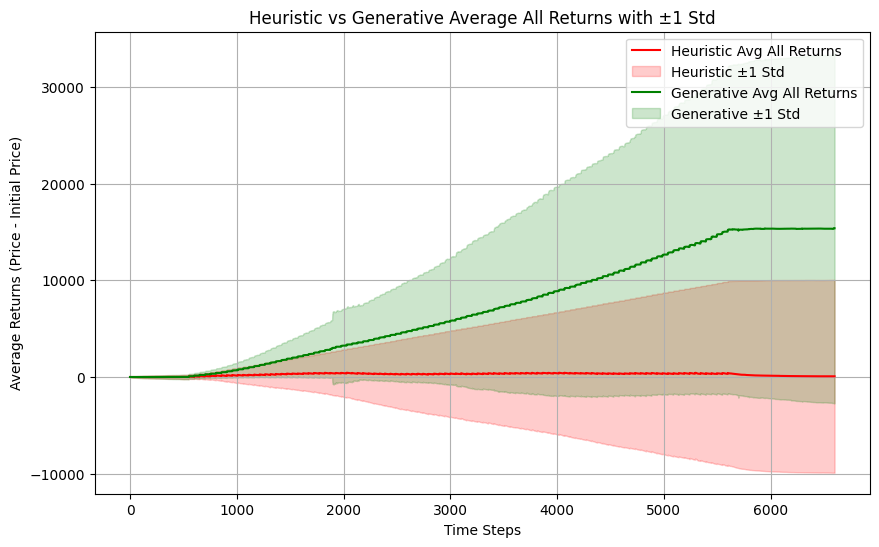

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Heuristic colors
heur_main_color = 'red'
heur_band_color = 'red'

# Generative colors
gen_main_color = 'green'
gen_band_color = 'green'

# Plot Heuristic
plt.plot(
    heuristic_avg_all_returns,
    label='Heuristic Avg All Returns',
    color=heur_main_color
)
plt.fill_between(
    np.arange(len(heuristic_avg_all_returns)),
    heuristic_avg_all_returns - heuristic_std_all_returns,
    heuristic_avg_all_returns + heuristic_std_all_returns,
    color=heur_band_color,
    alpha=0.2,
    label='Heuristic ±1 Std'
)

# Plot Generative
plt.plot(
    generative_avg_all_returns,
    label='Generative Avg All Returns',
    color=gen_main_color
)
plt.fill_between(
    np.arange(len(generative_avg_all_returns)),
    generative_avg_all_returns - generative_std_all_returns,
    generative_avg_all_returns + generative_std_all_returns,
    color=gen_band_color,
    alpha=0.2,
    label='Generative ±1 Std'
)

plt.title('Heuristic vs Generative Average All Returns with ±1 Std')
plt.xlabel('Time Steps')
plt.ylabel('Average Returns (Price - Initial Price)')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# # Create x-axis (time steps)
# x_axis = list(range(len(heuristic_all_returns)))

# # Create plotly figure
# fig = go.Figure()

# # Add lines with error bands (mean ± std) for Historical data
# # fig.add_trace(go.Scatter(
# #     x=x_axis + x_axis[::-1],
# #     y=np.concatenate([historical_avg_all_returns + historical_std_all_returns, (historical_avg_all_returns - historical_std_all_returns)[::-1]]),
# #     fill='toself',
# #     fillcolor='rgba(0, 0, 255, 0.2)',
# #     line=dict(color='rgba(255,255,255,0)'),
# #     hoverinfo="skip",
# #     showlegend=False
# # ))

# # fig.add_trace(go.Scatter(
# #     x=x_axis,
# #     y=historical_avg_all_returns,
# #     mode='lines',
# #     name=f'Historical - {len(historical_all_returns)} points',
# #     line=dict(color='blue', width=2)
# # ))

# # Add lines with error bands (mean ± std) for Heuristic data
# fig.add_trace(go.Scatter(
#     x=x_axis + x_axis[::-1],
#     y=np.concatenate([heuristic_avg_all_returns + heuristic_std_all_returns, (heuristic_avg_all_returns - heuristic_std_all_returns)[::-1]]),
#     fill='toself',
#     fillcolor='rgba(255, 0, 0, 0.2)',
#     line=dict(color='rgba(255,255,255,0)'),
#     hoverinfo="skip",
#     showlegend=False
# ))

# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=heuristic_avg_all_returns,
#     mode='lines',
#     name=f'Heuristic - {len(heuristic_all_returns)} points',
#     line=dict(color='red', width=2)
# ))

# # Add lines with error bands (mean ± std) for Generative data
# fig.add_trace(go.Scatter(
#     x=x_axis + x_axis[::-1],
#     y=np.concatenate([generative_avg_all_returns + generative_std_all_returns, (generative_avg_all_returns - generative_std_all_returns)[::-1]]),
#     fill='toself',
#     fillcolor='rgba(0, 255, 0, 0.2)',
#     line=dict(color='rgba(255,255,255,0)'),
#     hoverinfo="skip",
#     showlegend=False
# ))

# fig.add_trace(go.Scatter(
#     x=x_axis,
#     y=generative_avg_all_returns,
#     mode='lines',
#     name=f'Generative - {len(generative_all_returns)} points',
#     line=dict(color='green', width=2)
# ))

# # Update layout
# fig.update_layout(
#     title='Average Returns Evolution: Historical vs Heuristic vs Generative with ±1 Std',
#     xaxis_title='Time Steps',
#     yaxis_title='Average Returns (Price - Initial Price)',
#     width=1000,
#     height=600,
#     legend=dict(x=0.02, y=0.98)
# )

# fig.show()

# print(f"\nPlot created with returns (price - initial price) and standard deviation bands:")
# # print(f"- Historical data average (blue): {len(historical_all_returns)} samples")
# print(f"- Heuristic data average (red): {len(heuristic_all_returns)} samples")
# print(f"- Generative data average (green): {len(generative_all_returns)} samples")
# print(f"- Shaded areas represent ±1 standard deviation")


# m_dicts and b_dicts

## generative m_dicts and b_dicts

In [16]:
with open('/app/data_saved/exp_buy_85_sell_89/b_dict_buy.pkl', 'rb') as f:
    b_dict_buy_full = pickle.load(f)

with open('/app/data_saved/exp_buy_85_sell_89/b_dict_sell.pkl', 'rb') as f:
    b_dict_sell_full = pickle.load(f)

with open('/app/data_saved/exp_buy_85_sell_89/m_dict_buy.pkl', 'rb') as f:
    m_dict_buy_full = pickle.load(f)

with open('/app/data_saved/exp_buy_85_sell_89/m_dict_sell.pkl', 'rb') as f:
    m_dict_sell_full = pickle.load(f)

b_dict_buy = {k: v for k, v in b_dict_buy_full.items() if k in common_sample_indices_set}
b_dict_sell = {k: v for k, v in b_dict_sell_full.items() if k in common_sample_indices_set}
m_dict_buy = {k: v for k, v in m_dict_buy_full.items() if k in common_sample_indices_set}
m_dict_sell = {k: v for k, v in m_dict_sell_full.items() if k in common_sample_indices_set}

m_dict_combined = {}
b_dict_combined = {}

for key, value in m_dict_buy.items():
    m_dict_combined[key] = value

for key, value in b_dict_buy.items():
    b_dict_combined[key] = value

for key, value in m_dict_sell.items():
    m_dict_combined[key + 1000000] = value

for key, value in b_dict_sell.items():
    b_dict_combined[key + 1000000] = value

print(f"Combined m_dict keys: {len(m_dict_combined)}")
print(f"Combined b_dict keys: {len(b_dict_combined)}")

generative_m_dict_combined = m_dict_combined
generative_b_dict_combined = b_dict_combined

# ===== sample_day_map =====

sample_day_map_sell = sample_day_map.copy()
sample_day_map_sell['sample_id'] = sample_day_map_sell['sample_id'] + 1000000

sample_day_map_combined = pd.concat([sample_day_map, sample_day_map_sell], ignore_index=True)

print(f"Original sample_day_map rows: {len(sample_day_map)}")
print(f"Combined sample_day_map rows: {len(sample_day_map_combined)}")
print(f"Buy sample_ids range: {sample_day_map['sample_id'].min()} - {sample_day_map['sample_id'].max()}")
print(f"Sell sample_ids range: {sample_day_map_sell['sample_id'].min()} - {sample_day_map_sell['sample_id'].max()}")

sample_day_map = sample_day_map_combined


Combined m_dict keys: 418
Combined b_dict keys: 418
Original sample_day_map rows: 1024
Combined sample_day_map rows: 2048
Buy sample_ids range: 6 - 3328
Sell sample_ids range: 1000006 - 1003328


In [17]:
# heuristic_buy_m_dict, heuristic_buy_b_dict = process_m_b_data(experiment_name_heuristic_merged_buy)
# heuristic_sell_m_dict, heuristic_sell_b_dict = process_m_b_data(experiment_name_heuristic_merged_sell)
# historical_buy_m_dict, historical_buy_b_dict = process_m_b_data(experiment_name_historical_merged_buy)
# historical_sell_m_dict, historical_sell_b_dict = process_m_b_data(experiment_name_historical_merged_sell)

# # Save heuristic buy dictionaries
# with open(f"/app/data_saved/{experiment_name_heuristic_merged_buy}/heuristic_buy_m_dict.pkl", 'wb') as f:
#     pickle.dump(heuristic_buy_m_dict, f)
# with open(f"/app/data_saved/{experiment_name_heuristic_merged_buy}/heuristic_buy_b_dict.pkl", 'wb') as f:
#     pickle.dump(heuristic_buy_b_dict, f)

# # Save heuristic sell dictionaries
# with open(f"/app/data_saved/{experiment_name_heuristic_merged_sell}/heuristic_sell_m_dict.pkl", 'wb') as f:
#     pickle.dump(heuristic_sell_m_dict, f)
# with open(f"/app/data_saved/{experiment_name_heuristic_merged_sell}/heuristic_sell_b_dict.pkl", 'wb') as f:
#     pickle.dump(heuristic_sell_b_dict, f)

# # Save historical buy dictionaries
# with open(f"/app/data_saved/{experiment_name_historical_merged_buy}/historical_buy_m_dict.pkl", 'wb') as f:
#     pickle.dump(historical_buy_m_dict, f)
# with open(f"/app/data_saved/{experiment_name_historical_merged_buy}/historical_buy_b_dict.pkl", 'wb') as f:
#     pickle.dump(historical_buy_b_dict, f)

# # Save historical sell dictionaries
# with open(f"/app/data_saved/{experiment_name_historical_merged_sell}/historical_sell_m_dict.pkl", 'wb') as f:
#     pickle.dump(historical_sell_m_dict, f)
# with open(f"/app/data_saved/{experiment_name_historical_merged_sell}/historical_sell_b_dict.pkl", 'wb') as f:
#     pickle.dump(historical_sell_b_dict, f)


In [18]:
# Load heuristic buy dictionaries
with open(f"/app/data_saved/{experiment_name_heuristic_merged_buy}/heuristic_buy_m_dict.pkl", 'rb') as f:
    heuristic_buy_m_dict = pickle.load(f)
with open(f"/app/data_saved/{experiment_name_heuristic_merged_buy}/heuristic_buy_b_dict.pkl", 'rb') as f:
    heuristic_buy_b_dict = pickle.load(f)

# Load heuristic sell dictionaries
with open(f"/app/data_saved/{experiment_name_heuristic_merged_sell}/heuristic_sell_m_dict.pkl", 'rb') as f:
    heuristic_sell_m_dict = pickle.load(f)
with open(f"/app/data_saved/{experiment_name_heuristic_merged_sell}/heuristic_sell_b_dict.pkl", 'rb') as f:
    heuristic_sell_b_dict = pickle.load(f)

# Load historical buy dictionaries
# with open(f"/app/data_saved/{experiment_name_historical_merged_buy}/historical_buy_m_dict.pkl", 'rb') as f:
#     historical_buy_m_dict = pickle.load(f)
# with open(f"/app/data_saved/{experiment_name_historical_merged_buy}/historical_buy_b_dict.pkl", 'rb') as f:
#     historical_buy_b_dict = pickle.load(f)

# # Load historical sell dictionaries
# with open(f"/app/data_saved/{experiment_name_historical_merged_sell}/historical_sell_m_dict.pkl", 'rb') as f:
#     historical_sell_m_dict = pickle.load(f)
# with open(f"/app/data_saved/{experiment_name_historical_merged_sell}/historical_sell_b_dict.pkl", 'rb') as f:
#     historical_sell_b_dict = pickle.load(f)

In [19]:
heuristic_buy_m_dict = {k: v for k, v in heuristic_buy_m_dict.items() if k in common_sample_indices_set}
heuristic_buy_b_dict = {k: v for k, v in heuristic_buy_b_dict.items() if k in common_sample_indices_set}
heuristic_sell_m_dict = {k: v for k, v in heuristic_sell_m_dict.items() if k in common_sample_indices_set}
heuristic_sell_b_dict = {k: v for k, v in heuristic_sell_b_dict.items() if k in common_sample_indices_set}
# historical_buy_m_dict = {k: v for k, v in historical_buy_m_dict.items() if k in common_sample_indices_set}
# historical_buy_b_dict = {k: v for k, v in historical_buy_b_dict.items() if k in common_sample_indices_set}
# historical_sell_m_dict = {k: v for k, v in historical_sell_m_dict.items() if k in common_sample_indices_set}
# historical_sell_b_dict = {k: v for k, v in historical_sell_b_dict.items() if k in common_sample_indices_set}


print(f"heuristic_buy_m_dict keys: {len(heuristic_buy_m_dict)}")
print(f"heuristic_buy_b_dict keys: {len(heuristic_buy_b_dict)}")

heuristic_buy_m_dict keys: 72
heuristic_buy_b_dict keys: 72


In [20]:
heuristic_m_dict_combined = {}
heuristic_b_dict_combined = {}

for key, value in heuristic_buy_m_dict.items():
    heuristic_m_dict_combined[key] = value

for key, value in heuristic_buy_b_dict.items():
    heuristic_b_dict_combined[key] = value

for key, value in heuristic_sell_m_dict.items():
    heuristic_m_dict_combined[key + 1000000] = value

for key, value in heuristic_sell_b_dict.items():
    heuristic_b_dict_combined[key + 1000000] = value

# historical_m_dict_combined = {}
# historical_b_dict_combined = {}

# for key, value in historical_buy_m_dict.items():
#     historical_m_dict_combined[key] = value

# for key, value in historical_buy_b_dict.items():
#     historical_b_dict_combined[key] = value

# for key, value in historical_sell_m_dict.items():
#     historical_m_dict_combined[key + 1000000] = value

# for key, value in historical_sell_b_dict.items():
#     historical_b_dict_combined[key + 1000000] = value

# print(f"Combined heuristic m_dict keys: {len(heuristic_m_dict_combined)}")
# print(f"Combined heuristic b_dict keys: {len(heuristic_b_dict_combined)}")
# print(f"Combined historical m_dict keys: {len(historical_m_dict_combined)}")
# print(f"Combined historical b_dict keys: {len(historical_b_dict_combined)}")

In [21]:
# ---- run it (using your objects) ----
interactive_lob_plot(heuristic_b_dict_combined, heuristic_m_dict_combined,
                     l2_start=210, l2_end=293,     # <- your current visualization window
                     ask_before_bid=True,          # <- flip to False if your storage is BID|ASK
                     odd_policy="drop_center",     # <- drop the center column when width is odd
                     use_abs=True)                 # <- abs-sum avoids sign cancellation

FigureWidget({
    'data': [{'marker': {'color': 'orange'},
              'type': 'bar',
              'uid': '4cfed366-1e24-4b1a-ab9f-eb4cfaa0f3de',
              'x': {'bdata': ('19jZ2tvc3d7f4OHi4+Tl5ufo6err7O' ... 'QVFhcYGRobHB0eHyAhIiMkJSYnKCk='),
                    'dtype': 'i1'},
              'xaxis': 'x',
              'y': {'bdata': ('AAAAAAAAAAAAAAAAAAAAAAAAAAAAAA' ... 'AAAAAAAAAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f4'},
              'yaxis': 'y'},
             {'marker': {'color': [orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, orange, orange, orange, orange, orange,
                                   orange, red, red, red, red, red, red, red, red,
                   

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Ask queued volume',
              'type': 'scatter',
              'uid': '69fddc0b-cb51-4b79-bbec-3ea3dde74bee',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... '4ZvxnAGcEZwhnDGcQZxRnGGccZyBk='),
                    'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAAAABhuB4TQAAAAMgehR' ... 'A727kvQAAAgDvbuS9AAACAO9u5L0A='),
                    'dtype': 'f8'}},
             {'mode': 'lines',
              'name': 'Bid queued volume',
              'type': 'scatter',
              'uid': '1ef20510-b2c7-4970-83bd-1dfb37dac5eb',
              'x': {'bdata': ('AAABAAIAAwAEAAUABgAHAAgACQAKAA' ... '4ZvxnAGcEZwhnDGcQZxRnGGccZyBk='),
                    'dtype': 'i2'},
              'y': {'bdata': ('AAAAAAAAAAAAAADa9SgLQAAAANr1KA' ... 'Cm7Tw8QAAAAKbtPDxAAAAApu08PEA='),
                    'dtype': 'f8'}},
             {'mode': 'lines',
              'name': 'Total queued volume',
              'type

HTML(value='<b>Queued volume @ t=1:</b>  Bid=5 • Ask=3 • Total=8')

HTML(value='<b>Limit • Sell • abs=858000 • rel=2 • size=100</b><br>raw: [110575862, 1, 0, 858000, 2, 100, 0, 2…

In [22]:
def calculate_impact(messages, valid_insertions, reference_price):
    """
    Calculate market impact for each insertion.
    
    Parameters
    ----------
    messages : np.array
        Message array with columns [EVENT_TYPE, DIRECTION, PRICE, REL, SIZE, ...]
    valid_insertions : list
        List of insertion indices
    reference_price : float
        Reference price at first insertion
        
    Returns
    -------
    impact : np.array
        Absolute impact for each insertion
    vwap_series : np.array
        VWAP series for each insertion
    Q_cum : np.array
        Cumulative quantity for each insertion
    log_imp : np.array
        Log of impact values for plotting
    """
    PRICE_COL = 3
    SIZE_COL = 5
    insert_sizes = messages[valid_insertions, SIZE_COL].astype(float)
    insert_prices = messages[valid_insertions, PRICE_COL].astype(float)
    Q_cum = np.cumsum(insert_sizes)
    notional = np.cumsum(insert_sizes * insert_prices)

    vwap_series = notional / np.maximum(Q_cum, 1e-12)
    # vwap_series = insert_prices
    
    impact = np.abs(vwap_series - reference_price) / reference_price
    
    # Calculate log impact for plotting (y-axis)
    eps = 1e-12
    log_imp = np.log(np.maximum(impact, eps))
    
    return impact, vwap_series, Q_cum, log_imp


def calculate_market_volume(messages, hist_steps, valid_insertions, execution_sum):
    """
    Calculate market execution volume V_exp for each insertion and return x-axis values for plotting.
    
    Parameters
    ----------
    messages : np.array
        Message array with columns [EVENT_TYPE, DIRECTION, PRICE, REL, SIZE, ...]
    hist_steps : int
        Starting index for market volume calculation
    valid_insertions : list
        List of insertion indices
    execution_sum : float
        Total execution sum for the day
        
    Returns
    -------
    V_exp : np.array
        Market volume from hist_steps to (idx-1) for each insertion
    log_qv : np.array
        Log of Q/V_exp ratio for plotting (x-axis)
    """
    EVENT_TYPE_COL = 1
    SIZE_COL = 5
    
    evt_types = messages[:, EVENT_TYPE_COL].astype(int)
    exec_sizes = np.where(evt_types == 4, messages[:, SIZE_COL].astype(float), 0.0)
    cum_exec_vol = np.cumsum(exec_sizes)
    
    V_exp = np.array([float(cum_exec_vol[idx-1] - cum_exec_vol[hist_steps-1] if (idx-1) >= hist_steps else 0.0)
                      for idx in valid_insertions])

    # Use execution_sum instead of fixed value
    V_exp = np.full_like(V_exp, execution_sum)
    
    # Calculate cumulative quantity for Q/V_exp ratio
    insert_sizes = messages[valid_insertions, SIZE_COL].astype(float)
    Q_cum = np.cumsum(insert_sizes)
    
    # Calculate log(Q/V_exp) for plotting (x-axis)
    eps = 1e-12
    rel_size = Q_cum / np.maximum(V_exp, eps)
    log_qv = np.log(np.maximum(rel_size, eps))

    return V_exp, log_qv

In [23]:
# Different methods of impact regression
import numpy as np

# ---------- small utils ----------
def _as_float(a):
    return np.asarray(a, dtype=float)

def _mask_xy(x, y):
    x = _as_float(x); y = _as_float(y)
    m = np.isfinite(x) & np.isfinite(y) & (x != 0.0)
    return x[m], y[m], m

def _beta_wls_fixed_internal(x, y_adj, w):
    # Weighted regression of y_adj on x with intercept fixed at 0
    x = _as_float(x); y_adj = _as_float(y_adj); w = _as_float(w)
    m = np.isfinite(x) & np.isfinite(y_adj) & np.isfinite(w) & (x != 0) & (w > 0)
    if m.sum() < 2: return np.nan
    xw = x[m] * np.sqrt(w[m]); yw = y_adj[m] * np.sqrt(w[m])
    denom = np.dot(xw, xw)
    if denom <= 0: return np.nan
    return float(np.dot(xw, yw) / denom)

# ---------- estimators (fixed intercept y = alpha + beta * x) ----------
def _beta_ols_fixed(x, y, alpha):
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    denom = np.dot(x, x)
    if denom <= 0: return np.nan
    return float(np.dot(x, y_adj) / denom)

def _beta_huber_fixed(x, y, alpha, c=1.345, max_iter=50, tol=1e-8):
    # Huber M via IRLS (defaults chosen for ~95% Gaussian efficiency)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    beta = _beta_ols_fixed(x, y, alpha)
    if not np.isfinite(beta): beta = 0.0
    for _ in range(max_iter):
        r = y_adj - beta * x
        med = np.median(r)
        sigma = 1.4826 * np.median(np.abs(r - med)) or (np.std(r) + 1e-12)
        u = r / (sigma + 1e-12)
        w = np.ones_like(u)
        big = np.abs(u) > c
        w[big] = (c / (np.abs(u[big]) + 1e-12))
        beta_new = _beta_wls_fixed_internal(x, y_adj, w)
        if not np.isfinite(beta_new): break
        if abs(beta_new - beta) <= tol * (1.0 + abs(beta)):
            beta = beta_new; break
        beta = beta_new
    return float(beta)

def _beta_lad_fixed(x, y, alpha, iters=100, eps=1e-8):
    # LAD (L1) via IRLS: w_i = 1/max(|r_i|, eps)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    beta = _beta_ols_fixed(x, y, alpha)
    if not np.isfinite(beta): beta = 0.0
    for _ in range(iters):
        r = y_adj - beta * x
        w = 1.0 / np.maximum(np.abs(r), eps)
        beta_new = _beta_wls_fixed_internal(x, y_adj, w)
        if not np.isfinite(beta_new): break
        if abs(beta_new - beta) <= 1e-7 * (1.0 + abs(beta)):
            beta = beta_new; break
        beta = beta_new
    return float(beta)

def _beta_ratio_median(x, y, alpha, x_floor=1e-6):
    # Median of ratios with |x| floor (avoid blow-ups near 0)
    x = _as_float(x); y_adj = _as_float(y) - _as_float(alpha)
    m = np.isfinite(x) & np.isfinite(y_adj) & (np.abs(x) >= x_floor)
    r = y_adj[m] / x[m]
    if r.size == 0: return np.nan
    return float(np.median(np.sort(r)))

def _beta_ratio_trim(x, y, alpha, x_floor=1e-6, trim=0.10):
    # Trimmed-mean of ratios (default 10% each tail) with |x| floor
    x = _as_float(x); y_adj = _as_float(y) - _as_float(alpha)
    m = np.isfinite(x) & np.isfinite(y_adj) & (np.abs(x) >= x_floor)
    r = np.sort(y_adj[m] / x[m])
    if r.size == 0: return np.nan
    k = int(trim * r.size)
    r = r[k: r.size - k] if r.size - 2*k > 0 else r
    return float(np.mean(r))

def _beta_deming_fixed(x, y, alpha, lambda_yx=1.0):
    # Orthogonal regression with fixed intercept (through origin on y_adj)
    x, y_adj, _ = _mask_xy(x, _as_float(y) - _as_float(alpha))
    if x.size < 2: return np.nan
    s_xx = np.dot(x, x) / x.size
    s_yy = np.dot(y_adj, y_adj) / x.size
    s_xy = np.dot(x, y_adj) / x.size
    if s_xy == 0.0: return np.nan
    A = s_yy - lambda_yx * s_xx
    B = 2.0 * s_xy
    disc = A*A + (B*B) * lambda_yx
    beta = (A + np.sqrt(disc)) / B
    return float(beta)

# ---------- single public entry ----------
def beta_fit(x, y, alpha, method="ols"):
    """
    Estimate beta in y = alpha + beta * x with a fixed intercept.

    Parameters
    ----------
    x, y : array-like
    alpha : float or array-like (broadcastable)
    method : {'ols','huber','lad','ratio-median','ratio-trim','deming'}

    Returns
    -------
    beta : float
    """
    m = method.lower()
    if m == "ols":
        return _beta_ols_fixed(x, y, alpha)
    elif m == "huber":
        return _beta_huber_fixed(x, y, alpha)           # c=1.345, 50 iters, tol=1e-8
    elif m == "lad":
        return _beta_lad_fixed(x, y, alpha)             # 100 iters, eps=1e-8
    elif m == "ratio-median":
        return _beta_ratio_median(x, y, alpha)          # x_floor=1e-6
    elif m == "ratio-trim":
        return _beta_ratio_trim(x, y, alpha)            # trim=10%, x_floor=1e-6
    elif m == "deming":
        return _beta_deming_fixed(x, y, alpha)          # lambda_yx=1.0
    else:
        raise ValueError(f"Unknown method '{method}'. Use one of: "
                         "ols, huber, lad, ratio-median, ratio-trim, deming.")

In [24]:
def market_impact_dashboard_from_raw(
    b_seq_inp,            # dict[id] -> np.array(T, ...), where col 0 = Δmid per step (ticks)
    msg_seq_raw,          # dict[id] -> np.array(T, num_fields)
    all_series,           # unused for mid now
    x,                    # time axis (len T) - unused here
    hist_steps=550,
    gen_block=50,
    num_insertions=20,
    *,
    beta_theory=0.5,
    samples_used=None,
    special_first=(79, 15),
    show_fit=True,
    tick_size=100,        # convert ticks -> dollars before calling helper funcs
):
    """
    Same UI/figure as before, but x/y are computed via your helper functions:
      - impact/log_imp from calculate_impact(...)
      - V_exp/log_qv from calculate_market_volume(...), now fed with day-level execution_sum from sample_day_map
    α is fixed to ln(eta_day), where eta_day = ln(H/L)/0.8325546 using H,L from the same sample_day_map.
    β is the fixed-intercept slope: mean((y - α) / x).
    """

    # ------------- normalize inputs -------------
    if isinstance(b_seq_inp, pd.DataFrame):
        b_dict_local = {int(r.id): np.array(r.merged_data) for _, r in b_seq_inp.iterrows()}
    else:
        b_dict_local = b_seq_inp
    if isinstance(msg_seq_raw, pd.DataFrame):
        m_dict_local = {int(r.id): np.array(r.merged_data) for _, r in msg_seq_raw.iterrows()}
    else:
        m_dict_local = msg_seq_raw

    EVENT_TYPE_COL = 1
    PRICE_COL      = 3
    SIZE_COL       = 5

    eps = 1e-12
    tol = 1e-12

    # -------------------- compute x_df, y_df, coeffs_df via helpers --------------------
    def compute_tables():
        sample_ids = sorted(set(b_dict_local.keys()) & set(m_dict_local.keys()))
        col_names = [f"ins_{i}" for i in range(1, num_insertions + 1)]
        x_df = pd.DataFrame(index=sample_ids, columns=col_names, dtype=object)
        y_df = pd.DataFrame(index=sample_ids, columns=col_names, dtype=object)
        coeff_rows = []

        for sid in sample_ids:
            messages_ticks = m_dict_local[sid]
            book = b_dict_local[sid]
            T = len(messages_ticks)

            # insertion schedule
            insertion_positions = hist_steps + np.arange(1, num_insertions + 1) * gen_block
            valid_insertions = [pos for pos in insertion_positions if pos < T]
            if not valid_insertions:
                coeff_rows.append({"sample_id": sid, "alpha_hat": np.nan, "beta_hat": np.nan,
                                   "n_used": 0, "n_total": 0})
                continue

            # Reference price at first insertion (ticks -> $)
            ref_idx = valid_insertions[0]
            reference_price = float(messages_ticks[ref_idx, PRICE_COL]) / tick_size

            # -------- NEW: get day info from sample_day_map --------
            # Look up this sample_id in sample_day_map
            try:
                day_row = sample_day_map[sample_day_map['sample_id'] == sid]
                if not day_row.empty:
                    H_ticks = float(day_row.iloc[0]['highest_price'])
                    L_ticks = float(day_row.iloc[0]['lowest_price'])
                    execution_sum = float(day_row.iloc[0]['execution_sum'])
                else:
                    # Fallback if not found: infer H/L from pre-gen window and use window exec sum
                    H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
                    L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
                    exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
                    execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))
            except Exception as _e:
                # Fallback if not found: infer H/L from pre-gen window and use window exec sum
                H_ticks = float(np.max(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.max(messages_ticks[:, PRICE_COL]))
                L_ticks = float(np.min(messages_ticks[:hist_steps, PRICE_COL])) if hist_steps <= T else float(np.min(messages_ticks[:, PRICE_COL]))
                exec_mask = (messages_ticks[:, EVENT_TYPE_COL].astype(int) == 4)
                execution_sum = float(np.sum(messages_ticks[exec_mask, SIZE_COL].astype(float)))

            # Convert to dollars for Parkinson eta
            H = float(H_ticks) / tick_size
            L = float(L_ticks) / tick_size
            if np.isfinite(H) and np.isfinite(L) and H > L and L > 0:
                eta_day = np.log(H / L) / 0.8325546
                alpha_fixed = float(np.log(max(eta_day, eps)))   # α = ln(η)
            else:
                eta_day = eps
                alpha_fixed = float(np.log(eta_day))

            # Convert messages to dollars for the helper functions
            messages_dollars = messages_ticks.astype(float).copy()
            messages_dollars[:, PRICE_COL] /= tick_size

            # --- use your helper functions (unchanged graphs) ---
            impact, vwap_series, Q_cum, log_imp = calculate_impact(
                messages_dollars, valid_insertions, reference_price
            )
            # -------- NEW: pass execution_sum from sample_day_map into V_exp calc --------
            V_exp, log_qv = calculate_market_volume(
                messages_dollars, hist_steps, valid_insertions, execution_sum
            )

            # fill tables per insertion (same)
            mask_zero = impact <= tol
            mask_pos  = ~mask_zero
            for j, _idx in enumerate(valid_insertions):
                col = f"ins_{j+1}"
                if mask_zero[j] or not np.isfinite(log_qv[j]) or not np.isfinite(log_imp[j]):
                    x_df.loc[sid, col] = "ZERO"
                    y_df.loc[sid, col] = "ZERO"
                else:
                    x_df.loc[sid, col] = float(log_qv[j])
                    y_df.loc[sid, col] = float(log_imp[j])

            # per-sample β with fixed intercept (same)
            used_x = log_qv[mask_pos]
            used_y = log_imp[mask_pos]
            n_used = int(used_x.size)
            n_total = int(len(valid_insertions))
            if n_used >= 2 and np.all(np.isfinite(used_x)) and np.all(np.isfinite(used_y)):
                valid_mask = (used_x != 0) & np.isfinite(used_x) & np.isfinite(used_y)
                if np.sum(valid_mask) >= 2:
                    # beta_hat = float(np.mean((used_y[valid_mask] - alpha_fixed) / used_x[valid_mask]))
                    beta_hat = beta_fit(used_x[valid_mask], used_y[valid_mask], alpha_fixed, method=est_method)                    
                else:
                    beta_hat = np.nan
            else:
                beta_hat = np.nan

            coeff_rows.append({
                "sample_id": sid,
                "alpha_hat": alpha_fixed,   # fixed ln(η_day) from sample_day_map
                "beta_hat": beta_hat,
                "n_used": n_used,
                "n_total": n_total,
            })

        coeffs_df = pd.DataFrame.from_records(coeff_rows).set_index("sample_id").sort_index()
        return x_df, y_df, coeffs_df

    x_df, y_df, coeffs_df = compute_tables()

    # -------------------- tidy points (unchanged) --------------------
    all_ids = list(x_df.index)
    ordered_ids = [sid for sid in special_first if sid in all_ids]
    ordered_ids += [sid for sid in sorted(all_ids) if sid not in ordered_ids]
    if samples_used is not None:
        ordered_ids = ordered_ids[:samples_used]

    rows = []
    for sid in ordered_ids:
        for j, col in enumerate(x_df.columns, start=1):
            xv = x_df.loc[sid, col]
            yv = y_df.loc[sid, col]
            if isinstance(xv, (int, float, np.floating)) and isinstance(yv, (int, float, np.floating)):
                if np.isfinite(xv) and np.isfinite(yv):
                    rows.append({"sample_id": sid, "insertion": j, "x": float(xv), "y": float(yv)})
    points_df = pd.DataFrame(rows)
    if points_df.empty:
        print("No numeric points to plot.")
        return None, pd.DataFrame(), pd.DataFrame(), {}

    data_max_ins = int(points_df["insertion"].max())
    max_insertions = int(min(num_insertions, data_max_ins))
    a_values = np.arange(1, max_insertions + 1)

    # -------------------- histogram data (unchanged) --------------------
    betas_clean = coeffs_df["beta_hat"].replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    beta_mean = float(betas_clean.mean()) if not betas_clean.empty else np.nan

    # -------------------- figure (unchanged) --------------------
    fig = go.FigureWidget(make_subplots(
        rows=2, cols=2,
        specs=[[{"type": "xy"}, {"type": "xy"}],
               [None,          {"type": "xy"}]],
        column_widths=[0.68, 0.32],
        row_heights=[0.55, 0.45],
        horizontal_spacing=0.07,
        vertical_spacing=0.12,
        subplot_titles=("Scatter & Global Fit", "β(a) evolution", "Distribution of β̂ across samples")
    ))

    LEGEND_MAX = 15
    palette = ["#1f77b4", "#d62728", "#2ca02c", "#9467bd", "#8c564b",
               "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#ff7f0e"]
    GREY = "rgba(0,0,0,0.25)"

    trace_meta = []
    for i, sid in enumerate(ordered_ids):
        sub = points_df[points_df["sample_id"] == sid].sort_values("insertion")
        x_vals = sub["x"].to_numpy()
        y_vals = sub["y"].to_numpy()
        ins = sub["insertion"].to_numpy()
        base_color = palette[i % len(palette)] if i != 1 else "#d62728"
        tr = go.Scatter(
            x=x_vals, y=y_vals, mode="markers",
            name=f"sample {sid} ({len(sub)}/{len(sub)} pts)",
            legendgroup=str(sid), showlegend=(i < LEGEND_MAX),
            marker=dict(size=7, color=base_color),
            hovertemplate=(
                "sample=%{customdata[0]}<br>"
                "ins=%{customdata[1]}<br>"
                "log(Q/V)=%{x:.4f}<br>"
                "log(Impact)=%{y:.4f}<extra></extra>"
            ),
            customdata=np.stack([sub["sample_id"].to_numpy(), ins], axis=1),
        )
        fig.add_trace(tr, row=1, col=1)
        trace_meta.append({"sid": sid, "ins": ins, "x": x_vals, "y": y_vals,
                           "base_color": base_color, "total": len(sub)})

    # global-fit trace (same)
    fit_trace_index = len(fig.data)
    fig.add_trace(
        go.Scatter(x=[], y=[], mode="lines", name="Global fit",
                   line=dict(dash="dash", width=2)),
        row=1, col=1
    )

    # ----- fitting helpers (unchanged, uses α_global = mean ln(η)) -----
    alpha_global = float(coeffs_df["alpha_hat"].mean(skipna=True)) if not coeffs_df.empty else 0.0

    def fit_for_mask(mask):
        X = points_df.loc[mask, "x"].to_numpy()
        Y = points_df.loc[mask, "y"].to_numpy()
        if len(Y) < 2:
            return np.nan, np.nan, np.nan, 0, np.array([]), np.array([])
        valid_mask = np.isfinite(X) & np.isfinite(Y) & (X != 0)
        if np.sum(valid_mask) < 2:
            return alpha_global, np.nan, np.nan, len(Y), np.array([]), np.array([])
        x_valid = X[valid_mask]; y_valid = Y[valid_mask]


        # ================================ #

        
        # beta = float(np.mean((y_valid - alpha_global) / x_valid))
        beta = beta_fit(x_valid, y_valid, alpha_global, method=est_method)
        

        # ================================ #
        
        y_pred = alpha_global + beta * X
        ss_tot = float(((Y - Y.mean()) ** 2).sum())
        ss_res = float(((Y - y_pred) ** 2).sum())
        r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        x_min, x_max = X.min(), X.max()
        x_line = np.linspace(x_min, x_max, 200)
        y_line = alpha_global + beta * x_line
        return alpha_global, beta, r2, len(Y), x_line, y_line

    # precompute β(a) & fit lines (unchanged)
    a_values = np.arange(1, max_insertions + 1)
    betas_evo = np.full_like(a_values, np.nan, dtype=float)
    fit_lines = {}
    for idx, a in enumerate(a_values):
        mask = points_df["insertion"] >= a
        alpha, beta, r2, n, x_line, y_line = fit_for_mask(mask)
        betas_evo[idx] = beta
        fit_lines[a] = (x_line, y_line, alpha, beta, r2, n)

    # β(a) and indicator (unchanged)
    beta_line_idx = len(fig.data)
    fig.add_trace(
        go.Scatter(x=a_values, y=betas_evo, mode="lines+markers", name="β(a)"),
        row=1, col=2
    )
    beta_vline_idx = len(fig.data)
    y_min = float(np.nanmin(betas_evo)) if np.isfinite(betas_evo).any() else 0.0
    y_max = float(np.nanmax(betas_evo)) if np.isfinite(betas_evo).any() else 1.0
    fig.add_trace(
        go.Scatter(x=[a_values[0], a_values[0]], y=[y_min, y_max],
                   mode="lines", line=dict(color="green", dash="dot"), name="current a"),
        row=1, col=2
    )

    # histogram β̂ (unchanged)
    if not betas_clean.empty:
        fig.add_trace(go.Histogram(x=betas_clean.values, nbinsx=30, name="β̂"), row=2, col=2)
        fig.add_trace(go.Scatter(x=[beta_mean, beta_mean], y=[0, max(1, len(betas_clean))],
                                 mode="lines", name=f"Mean β̂ = {beta_mean:.4f}",
                                 line=dict(dash="dash")), row=2, col=2)
        fig.add_trace(go.Scatter(x=[beta_theory, beta_theory], y=[0, max(1, len(betas_clean))],
                                 mode="lines", name=f"β = {beta_theory:.2f} (theoretical)",
                                 line=dict(dash="dot")), row=2, col=2)

    # axes & layout (unchanged)
    fig.update_xaxes(title_text="log(Q / V_exp)", row=1, col=1)
    fig.update_yaxes(title_text="log(Impact)", row=1, col=1)
    fig.update_xaxes(title_text="a (insertion threshold)", row=1, col=2)
    fig.update_yaxes(title_text="β (slope)", row=1, col=2)
    fig.update_xaxes(title_text="β̂", row=2, col=2)
    fig.update_yaxes(title_text="Frequency", row=2, col=2)

    fig.update_layout(template="plotly_white", width=1500, height=800,
                      margin=dict(t=70, r=50, b=60, l=60),
                      legend=dict(orientation="v"))

    # fit box (unchanged)
    def set_fit_annotation(text_html: str):
        fig.layout.annotations = tuple(
            a for a in (fig.layout.annotations or [])
            if getattr(a, "name", "") != "fit_box"
        )
        fig.add_annotation(
            x=0.02, y=0.18, xref="paper", yref="paper",
            text=text_html, showarrow=False, align="left",
            bordercolor="lightgray", borderwidth=1, borderpad=8,
            bgcolor="rgba(245,245,245,1)", name="fit_box"
        )

    def update_left_fit(a_val: int):
        x_line, y_line, alpha, beta, r2, n = fit_lines.get(a_val, ([], [], np.nan, np.nan, np.nan, 0))
        fig.data[fit_trace_index].x = x_line
        fig.data[fit_trace_index].y = y_line
        if show_fit and n > 0 and np.isfinite(beta):
            fit_html = (
                "<b>Market Impact Fit (Fixed Intercept)</b><br>"
                f"<b>a:</b> {a_val}<br>"
                f"<b>Model:</b> log(Impact) = <b>{alpha:.6f}</b> + <b>{beta:.6f}</b> · log(Q/V)<br>"
                f"<b>α (fixed):</b> {alpha:.6f} (mean ln(η) across samples)<br>"
                f"<b>β:</b> {beta:.6f}<br>"
                f"<b>R²:</b> {r2:.4f}<br>"
                f"<b>Used points:</b> {n}"
            )
        else:
            fit_html = f"<b>Market Impact Fit (Fixed Intercept)</b><br><b>a:</b> {a_val}<br>No active points."
        set_fit_annotation(fit_html)

    def recolor_and_refit(a_val: int):
        for t_idx, meta in enumerate(trace_meta):
            active_mask = meta["ins"] >= a_val
            colors = [meta["base_color"] if ok else GREY for ok in active_mask]
            fig.data[t_idx].marker.color = colors
            active_count = int(np.count_nonzero(active_mask))
            fig.data[t_idx].name = f"sample {meta['sid']} ({meta['total']}/{active_count} pts)"
        if show_fit:
            update_left_fit(a_val)

        y_min_local = float(np.nanmin(betas_evo)) if np.isfinite(betas_evo).any() else 0.0
        y_max_local = float(np.nanmax(betas_evo)) if np.isfinite(betas_evo).any() else 1.0
        fig.data[beta_vline_idx].x = [a_val, a_val]
        fig.data[beta_vline_idx].y = [y_min_local, y_max_local]

    # controls (unchanged)
    a_slider = widgets.IntSlider(value=1, min=1, max=max_insertions, step=1, description="a")
    prev_btn = widgets.Button(description="Prev", layout=widgets.Layout(width="80px"))
    next_btn = widgets.Button(description="Next", layout=widgets.Layout(width="80px"))

    def on_prev(_):
        if a_slider.value > a_slider.min:
            a_slider.value -= 1

    def on_next(_):
        if a_slider.value < a_slider.max:
            a_slider.value += 1

    def on_a_change(change):
        if change["name"] == "value":
            recolor_and_refit(change["new"])

    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)
    a_slider.observe(on_a_change, names="value")

    # initial render
    recolor_and_refit(a_slider.value)
    display(widgets.HBox([prev_btn, next_btn, a_slider]), fig)

    controls = {"a_slider": a_slider, "prev_btn": prev_btn, "next_btn": next_btn}
    return fig, points_df, coeffs_df, controls

In [25]:
experiment_name = 'exp_89_20250828_194553_gen_sell_1024'  #       exp_85_20250823_020427_1024
# filtration_name = 'samples_after_book_filtration_buy_1024_446'

CONFIG_PATH = f"/app/data_saved/{experiment_name}/used_config.yaml"

with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)
num_insertions      = config["num_insertions"]
num_coolings        = config["num_coolings"]
midprice_step_size  = config["midprice_step_size"]
hist_msgs           = config["n_messages"]
n_gen_msgs          = config["n_gen_msgs"]

hist_steps = hist_msgs // midprice_step_size       # 500
gen_steps = n_gen_msgs // midprice_step_size     # 50
gen_block = gen_steps + 1                        # 51

# x is just numbers from 1 to max len (all_series)
x = list(range(1, historical_all_returns.shape[1] + 1))

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:19                                                                                   │
│                                                                                                  │
│   16 gen_block = gen_steps + 1                        # 51                                       │
│   17                                                                                             │
│   18 # x is just numbers from 1 to max len (all_series)                                          │
│ ❱ 19 x = list(range(1, historical_all_returns.shape[1] + 1))                                     │
│   20                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
NameError: name 'historical_all_returns' is not defined

In [ ]:
# Plotly FigureWidget output removed due to previous file corruption.
# Re-run this visualization cell when you're ready; placeholder keeps notebook loadable.